## Exercise 5, Experiment notebook
_Using `KNN`_

<br>
<br>




### Dataset: [Faulty Steel Plates](https://www.kaggle.com/datasets/uciml/faulty-steel-plates)

|Parameter|Description|
|---|---|
|Shape|_`1941 rows, 35 columns`_|
|Target Variable|_`Bumps`_|
|Method:|_``_|
|Extra Tools:|_``_|

<br>

#### Column Descriptions:


<i>
Not available
</i>

<br>
<br>

#### Summary:

<u>Suspiciously high results?</u>

The prediction results for this model are suspiciously high. I've looked into it for a couple hours, but I haven't found out the culprit yet. If I have extra time, I'll look into it some more!



<u> Personal Analysis </u>

The obvious, the metrics are suspiciously high. I'll continue to look into that and research the topic. Maybe I'll find something out before it gets graded. If not, DARN. Here are some other thoughts:

* We can see that the number of neighbors used here is quite low. I suspect that's because the number of rows were very small, (~1k rows)

* Gridsearch optimized accuracy report scores by 9%. That is enormous. 

* No RFE or PCA was used, and I feel that was a good call. 20-30 features is still managable!

* I'm using less comments and explaining stuff a little less now, since it can be overwhelming. Let's see if that helps with readability. (If I know only I am reading it, I'm gonna comment a lot though.)



#### Results:
|Confusion Matrix|Accuracy Score| ROC AUC|
|---|---|---|
|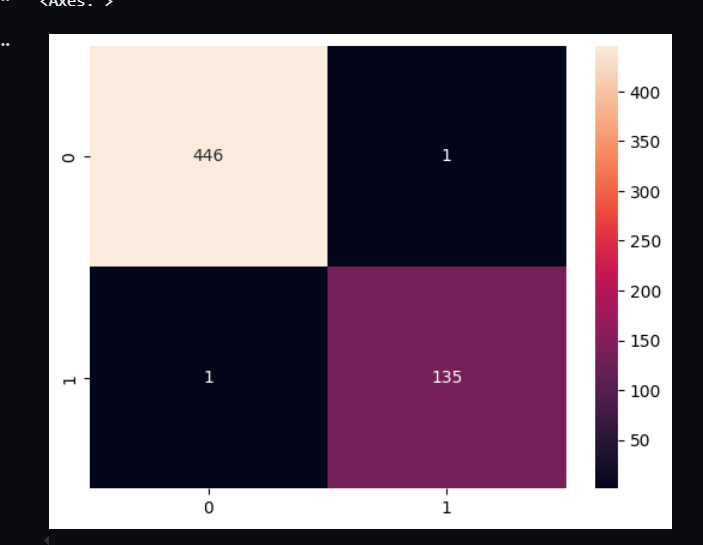|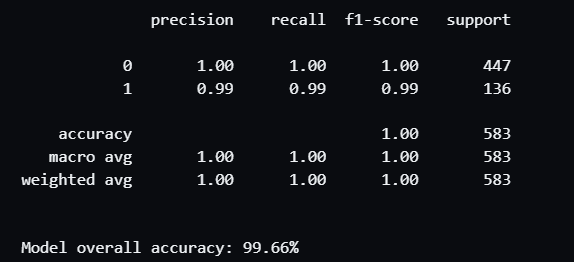|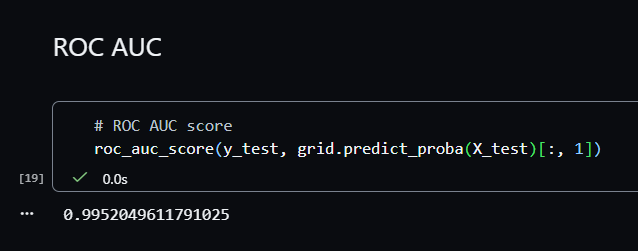|


<br>
<br>


---

## Code:

#### Imports and Data Loading

In [2]:
# Imports
import pandas as pd
import math
import numpy as np

import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# Loading dataframe
df = pd.read_csv("../datasets/faults.csv")
df.head(10)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0
5,430,441,100250,100337,630,20,87,62357,64,127,...,0.8736,-0.2267,0.9874,1,0,0,0,0,0,0
6,413,446,138468,138883,9052,230,432,1481991,23,199,...,0.9205,0.2791,1.0000,1,0,0,0,0,0,0
7,190,200,210936,210956,132,11,20,20007,124,172,...,0.5000,0.1841,0.3359,1,0,0,0,0,0,0
8,330,343,429227,429253,264,15,26,29748,53,148,...,0.5000,-0.1197,0.5593,1,0,0,0,0,0,0
9,74,90,779144,779308,1506,46,167,180215,53,143,...,0.9024,-0.0651,1.0000,1,0,0,0,0,0,0


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Training & Metrics|

#### Checking the Shape


In [3]:
# Let's check the amount of rows and columns
df.shape

(1941, 34)

#### Handling Missing Values

<i>
Pray we don't have missing values

In [4]:
# Checking for missing values
df.isna().sum()

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Pastry                   0
Z_Scratch                0
K_Scatch                 0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64

#### Handling Duplicates

<i>
Any duplicates?

In [5]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

#### Handling Isolated Case values

In [6]:
# Since we have a metric ton of columns, let's make a for-loop that 
# gives the value counts of all the columns that may have isolated cases.
list_checkable_columns = list(df.columns)

for column in list_checkable_columns:
    print(df[column].value_counts())
    print()


# Lots of skewed distributions. 

X_Minimum
41      126
39      125
0        38
43       18
37       12
       ... 
122       1
983       1
1275      1
1398      1
1557      1
Name: count, Length: 962, dtype: int64

X_Maximum
212     23
214     22
218     21
216     19
194     14
        ..
684      1
848      1
1409     1
1371     1
141      1
Name: count, Length: 994, dtype: int64

Y_Minimum
1803992    2
28972      2
87951      1
270900     1
3411415    1
          ..
1538494    1
1563477    1
2867489    1
2985008    1
3063739    1
Name: count, Length: 1939, dtype: int64

Y_Maximum
28984      2
2538108    1
1553931    1
369415     1
498335     1
          ..
1538509    1
1563499    1
2867513    1
2985026    1
87967      1
Name: count, Length: 1940, dtype: int64

Pixels_Areas
68      19
52      19
60      18
55      16
16      15
        ..
1097     1
728      1
433      1
480      1
442      1
Name: count, Length: 920, dtype: int64

X_Perimeter
12     81
15     75
13     71
14     69
11     58
       ..
71      1
186

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">Transformation</bold>|
|3| ML Training & Metrics|

<br>




#### Checking out the distribution of the target variable.

<Axes: xlabel='Bumps', ylabel='Count'>

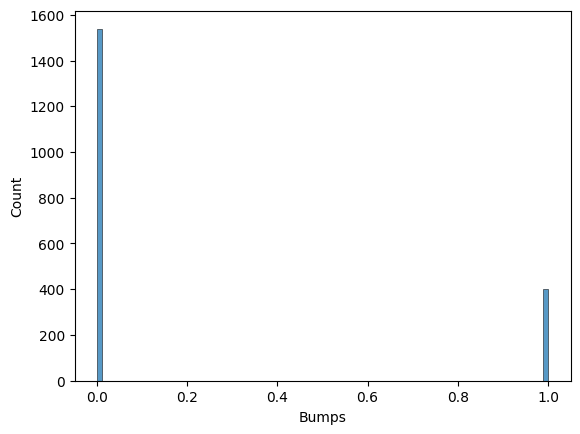

In [7]:
# Checking the distribution of the target variable.
sns.histplot(df, x='Bumps')

# Not great. 

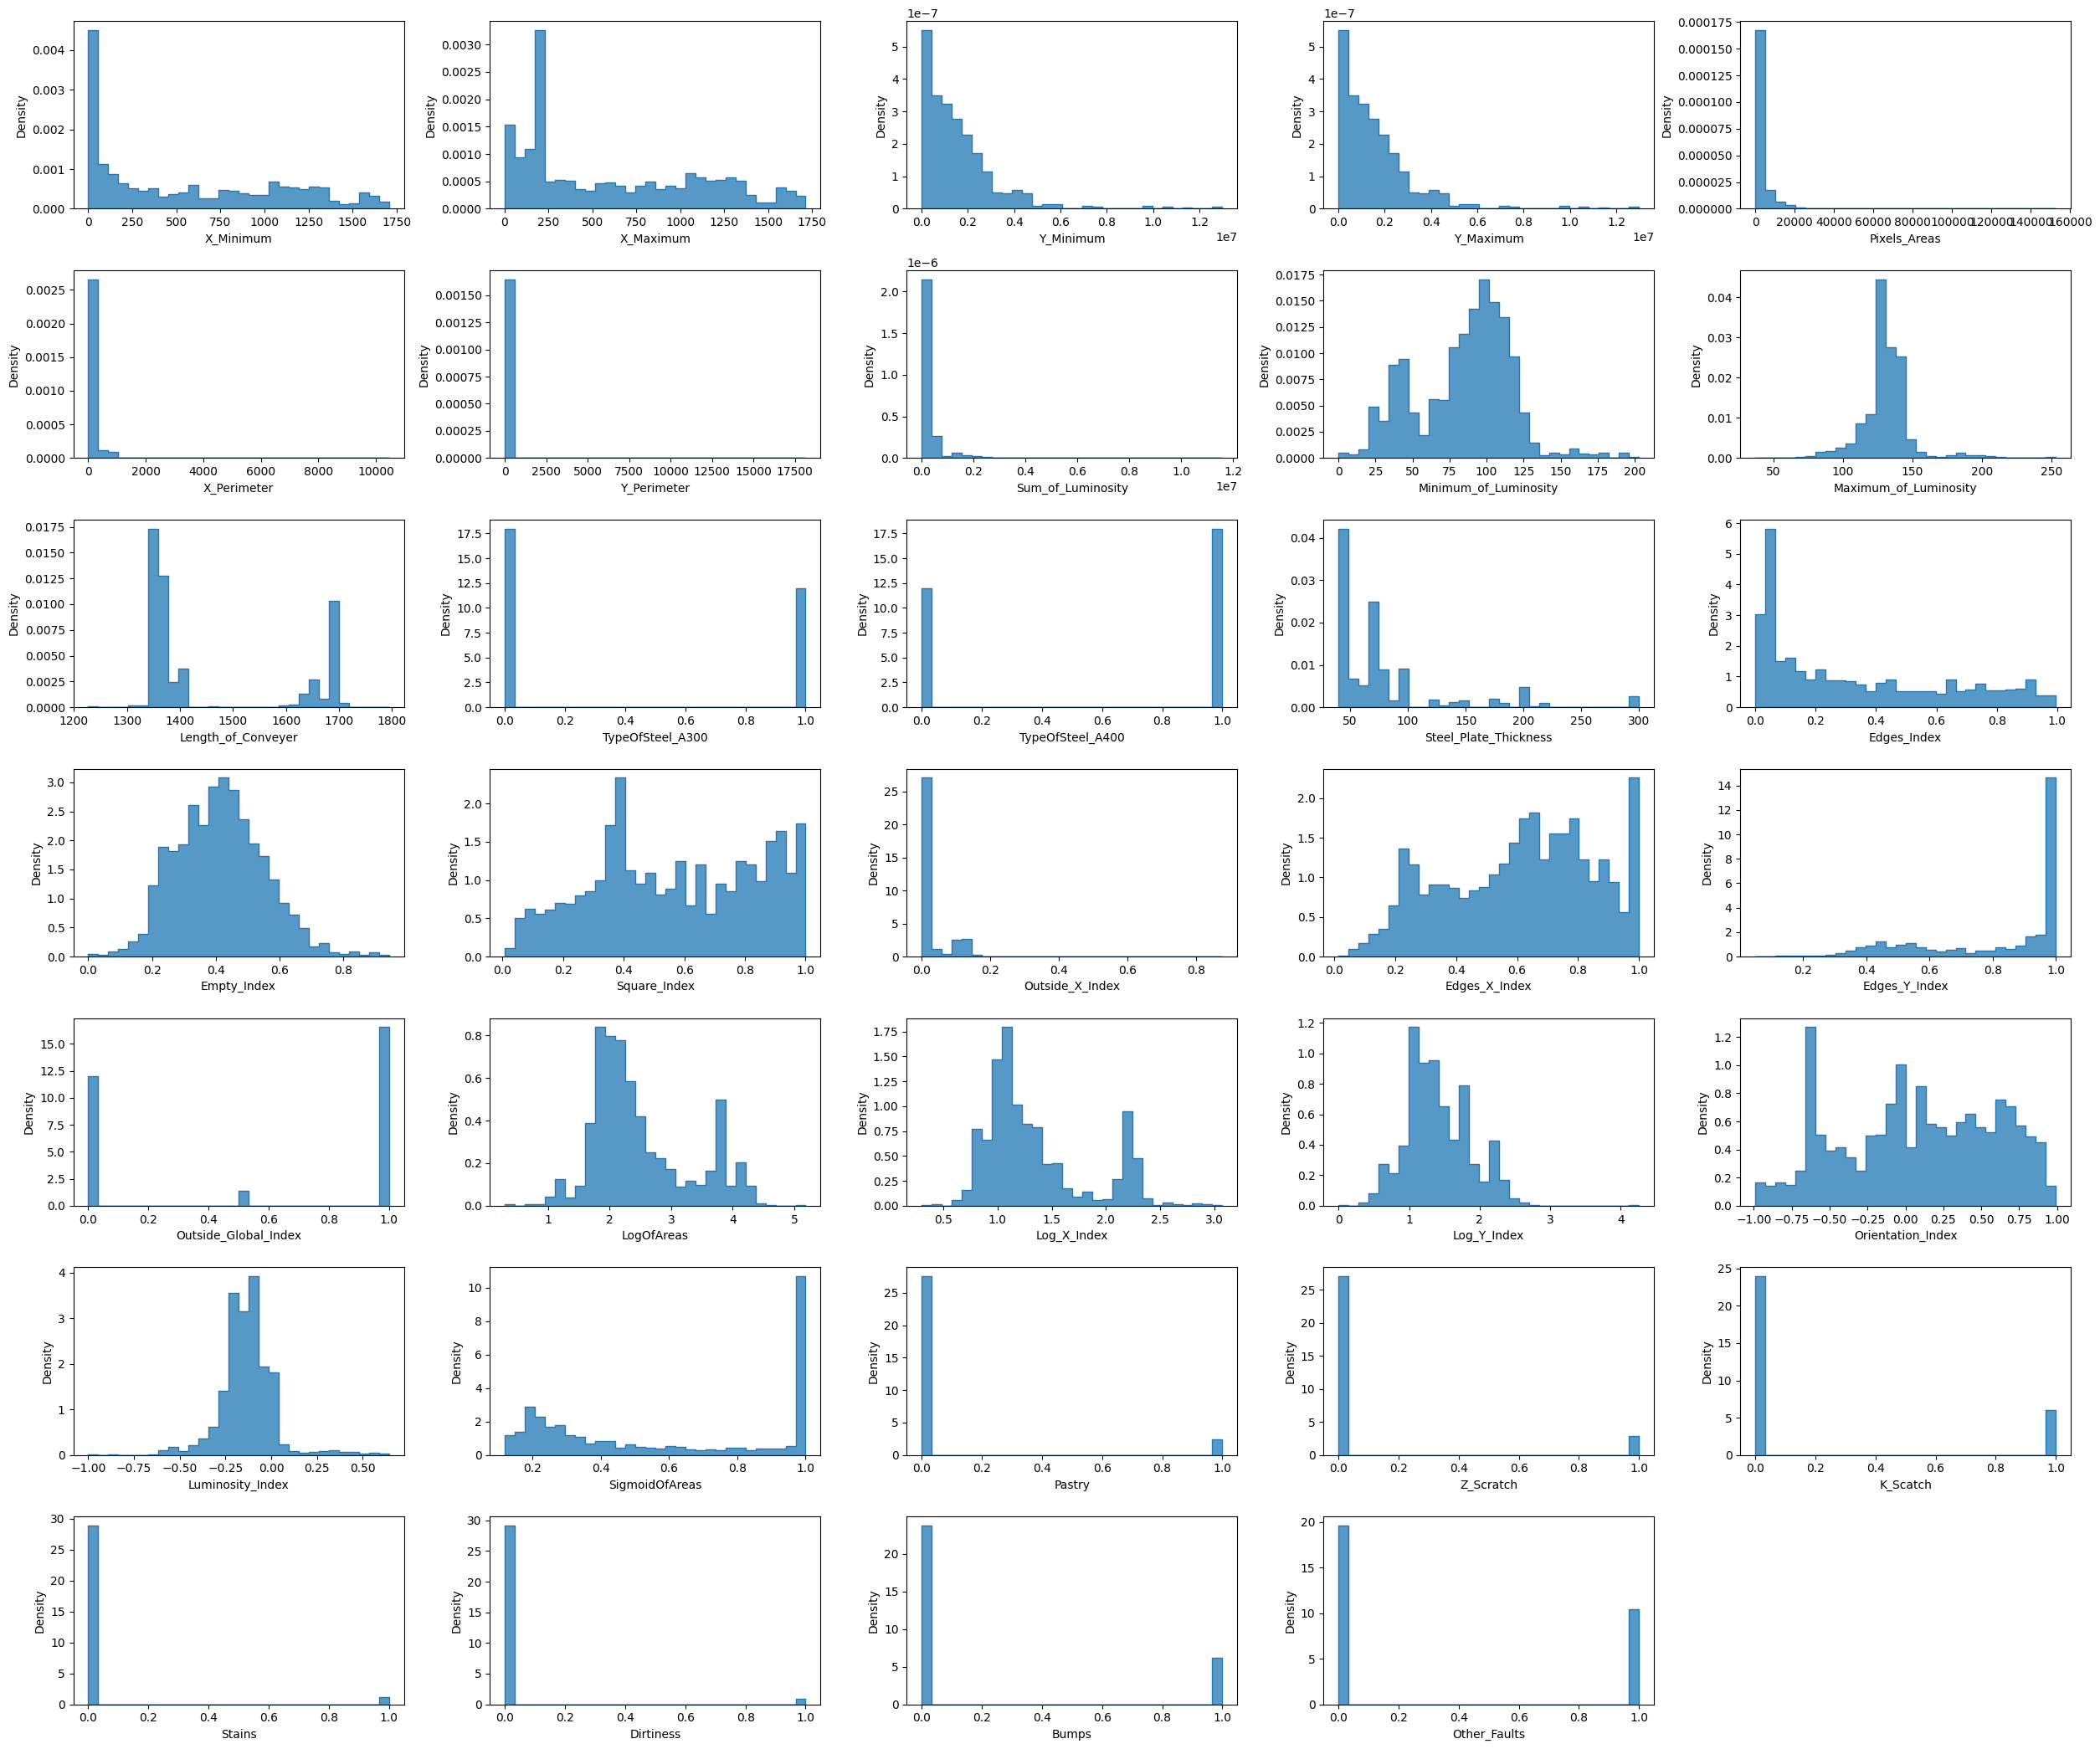

In [8]:


# This is a function I've been using to quickly check distributions.


def check_distributions(df, plots_per_row=5, hue=None):

    import math
    n_cols = len(df.columns)
    n_rows = math.ceil(n_cols / plots_per_row)

    # Create the canvas. Make it bigger/smaller depending on the number of plots per row.
    fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 3))
    axes = axes.flatten()

    # For each column and index, check if there's a hue and use it if there is,
    # don't plot the hue column with itself for distribution.
    for i, column in enumerate(df.columns):
        if column == hue:
            axes[i].set_visible(False)
            continue

        # Then make a histogram. Set the index where the plot is supposed to go.
        sns.histplot(
            df,
            x=column,
            hue=hue,
            ax=axes[i],
            bins=30,
            element="step",
            stat="density",
            common_norm=False 
        )


    # Get rid of plots that aren't used (they're annoying)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Avoids text overlap.
    plt.tight_layout()

# Running the function
check_distributions(df)

#### Analysis:

Some numeric columns have right-skew, Sigmoid has a left-skew. Otherwise, fairly clean. `StandardScaler()` will probably clean all of this up nicely. I'm a little concerned with the `Dirtiness` column. There aren't many cases for it. 

In [9]:
# Checking Dirtiness value counts.
df["Dirtiness"].value_counts()

# Seems ok actually.

Dirtiness
0    1886
1      55
Name: count, dtype: int64

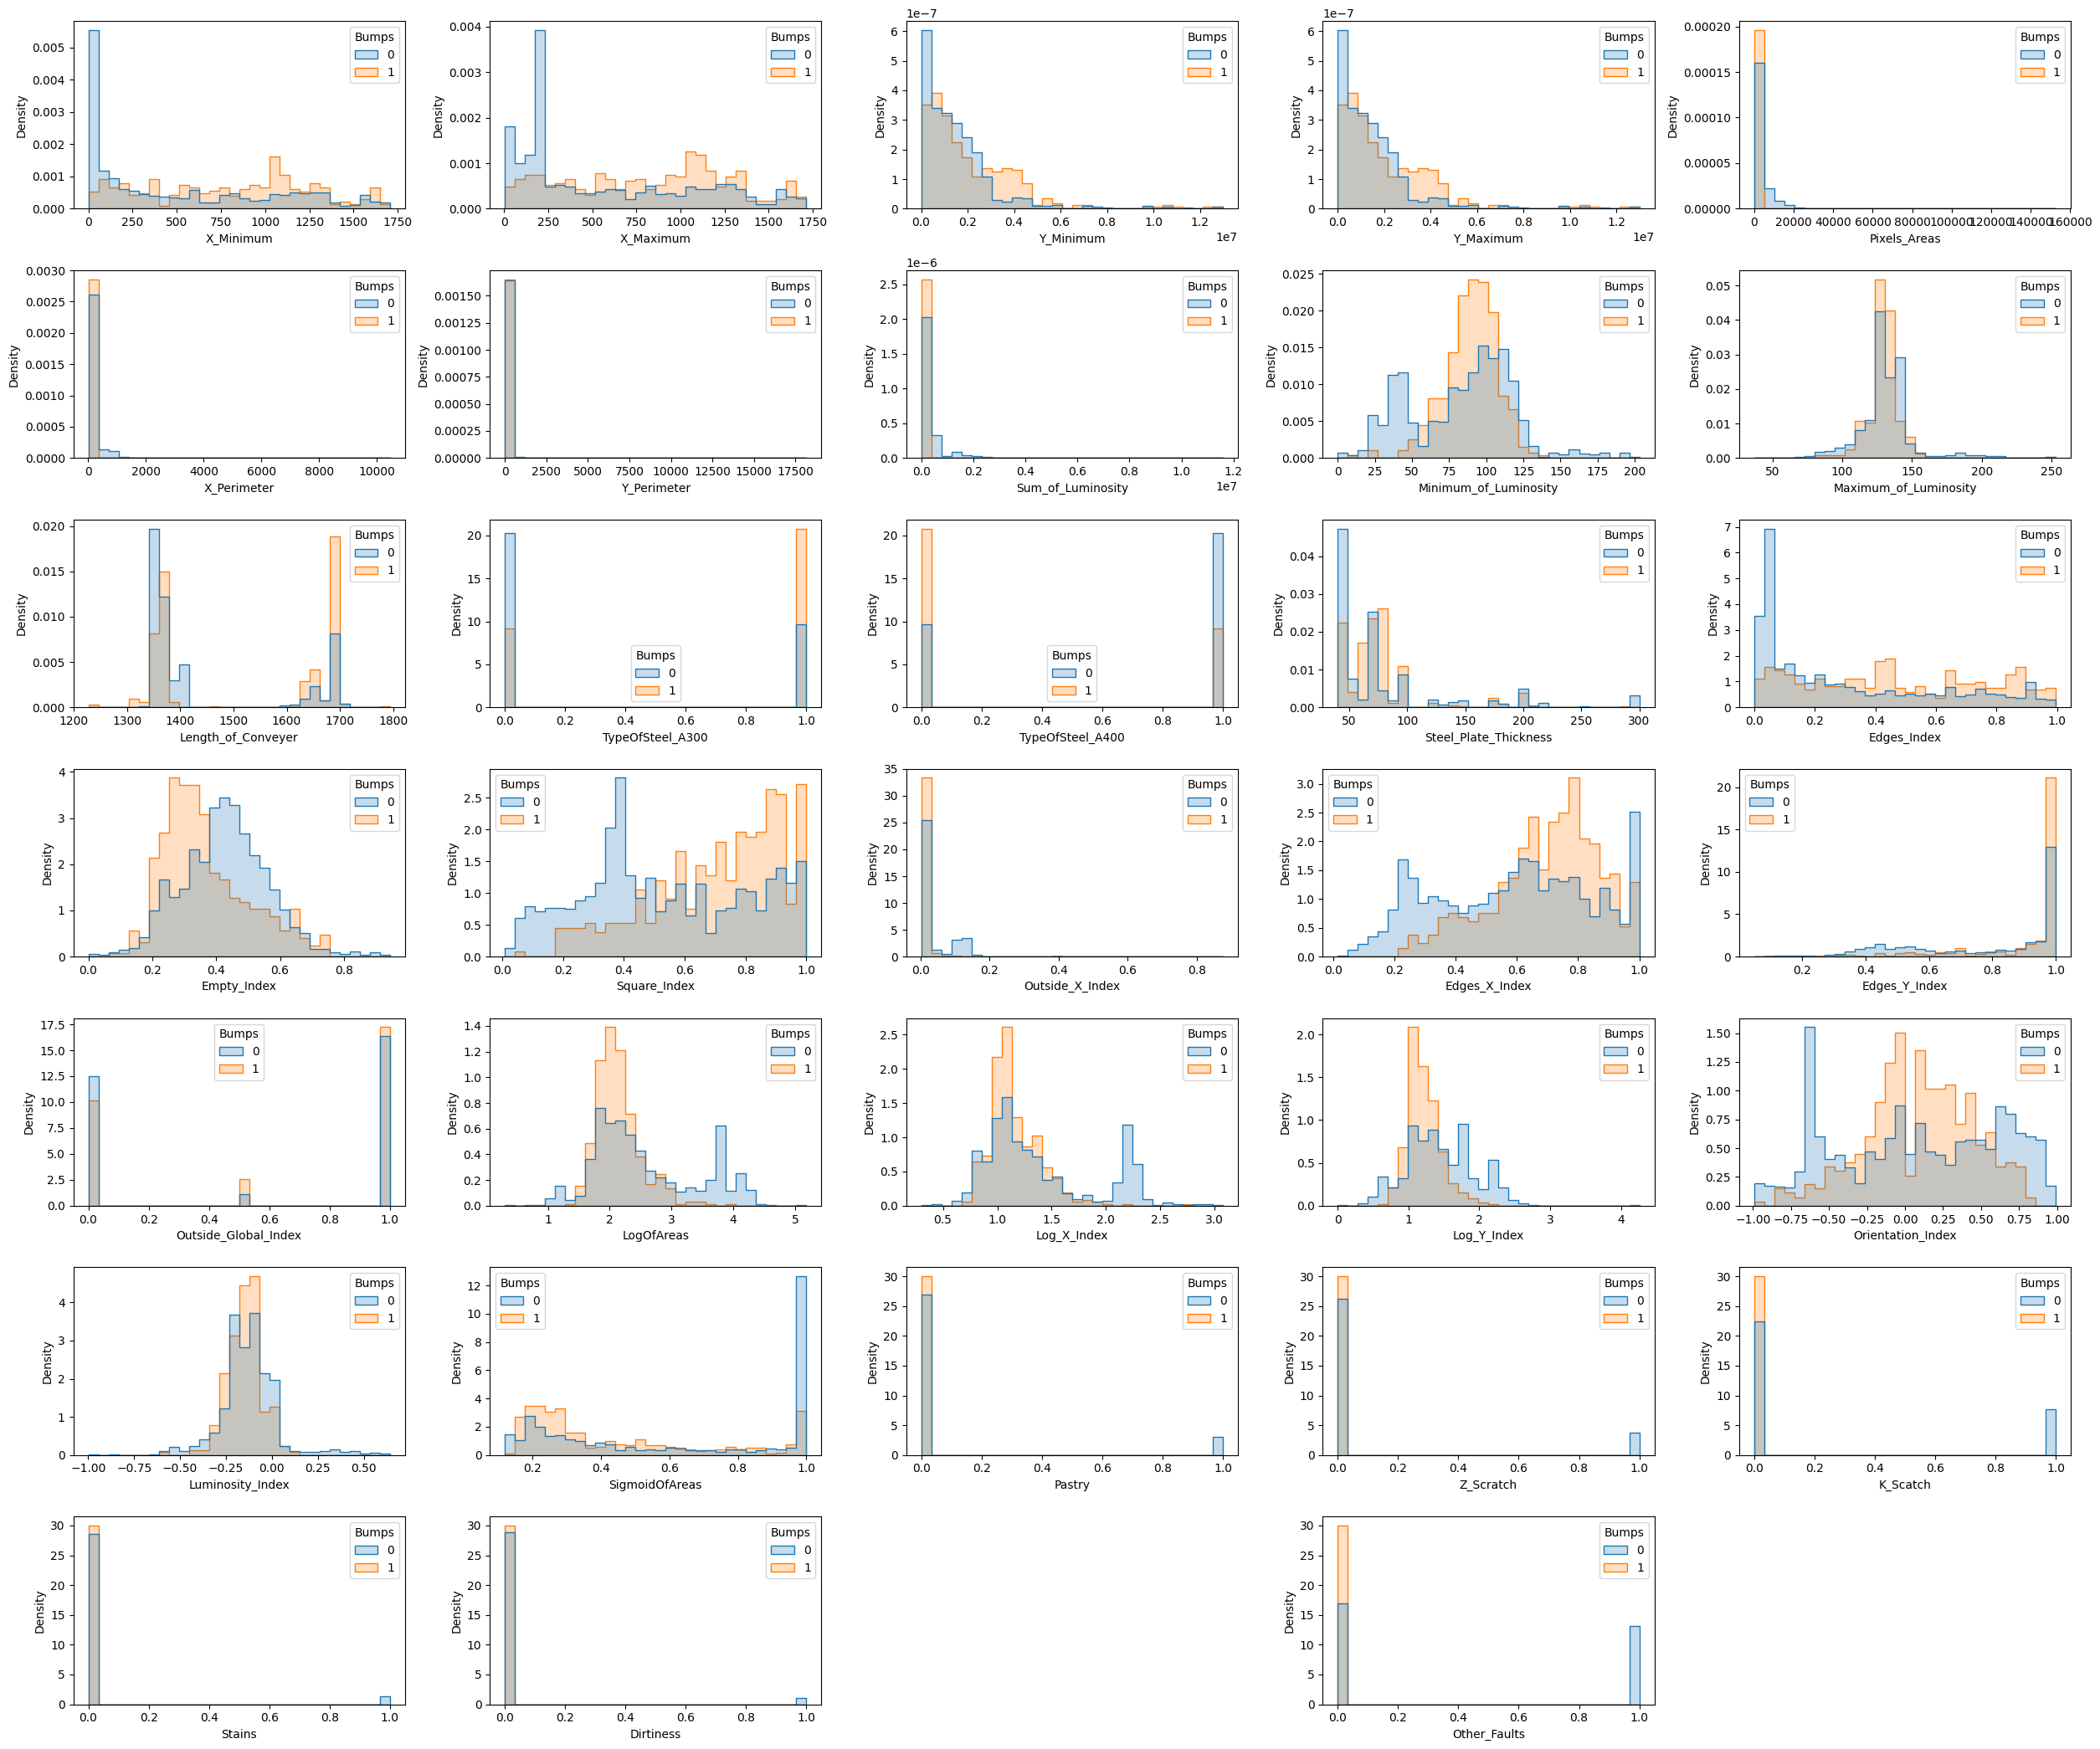

In [10]:
# Let's check the distribution with the hue as the target variable.
check_distributions(df, hue="Bumps")

# There does appear to be quite a bit of overlap in the 1D spectrum. Overlap is bad for KNN.


#### More Analysis:

I can't tell completely yet whether or not `KNN` is a good fit, but we're seeing quite a bit of overlap. Hopefully in a planar view, we can start to see more zones/isolation for groups. 

In [11]:
# Another function I made. It shows the strongest correlations. Tuomas inspired. 
def correlation_check(df, target):

    # Make a correlation matrix.
    correlation = df.corr(numeric_only=True)

    # Only see absolute value correlations.
    abs_correlation = abs(correlation[target])

    # Turn it into a dataframe.
    abs_corr_df = pd.DataFrame(abs_correlation).reset_index()

    # See the highest corrs (negative or positive.)
    abs_corr_df = abs_corr_df.sort_values(target, ascending=False)


    # return dataframe. 
    return abs_corr_df

correlation_df = correlation_check(df, "Bumps")
correlation_df

,index,Bumps
32,Bumps,1.000000
33,Other_Faults,0.372342
12,TypeOfSteel_A400,0.306385
11,TypeOfSteel_A300,0.306385
16,Square_Index,0.261385
29,K_Scatch,0.256694
14,Edges_Index,0.232000
19,Edges_Y_Index,0.229231
21,LogOfAreas,0.226490
10,Length_of_Conveyer,0.225504


<Axes: >

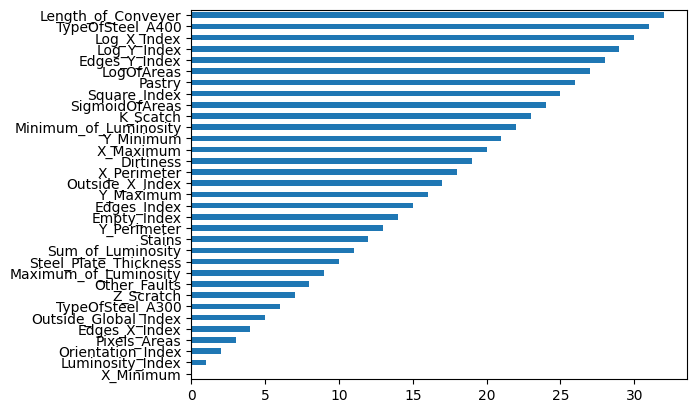

In [12]:
from skfeature.function.similarity_based import fisher_score
# pip install skfeature-chappers

# -- FISHER SCORE -- 

# Separate the target variable from the features
X = df.drop('Bumps', axis=1)
y = df['Bumps']

# Get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)

# Create a pandas series. Sort from highest to lowerst.
feat_importances = pd.Series(ranks, X.columns).sort_values()

# Create a bar chart to visualize.
feat_importances.plot(kind='barh')


In [13]:
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

X = df.drop("Bumps", axis=1)

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, confusing the logistic regression
vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
3,Y_Maximum,1.712054e+10
2,Y_Minimum,1.712031e+10
0,X_Minimum,4.292493e+04
1,X_Maximum,3.918523e+04
6,Y_Perimeter,1.586762e+03
21,LogOfAreas,1.190466e+03
17,Outside_X_Index,1.020735e+03
12,TypeOfSteel_A400,8.009246e+02
11,TypeOfSteel_A300,5.543606e+02
4,Pixels_Areas,5.245455e+02


#### Personal Analysis:

Not bad. The minimum values naturally correlate with the Maximum values. We'll test the performance whether or not it's better dropping 1 minimum and 1 maximum column.

#### Dropping Columns

Let's drop some columns that the above analysis gave us.

In [14]:
df.drop([
    "Luminosity_Index",               # Low correlation/fisher score
    "Steel_Plate_Thickness",          # Low correlation/fisher score
    "Orientation_Index",              # Low correlation/fisher score
    "Pixels_Areas",                   # Irrelevant
    "Outside_Global_Index",           # Low correlation/fisher score
    "Maximum_of_Luminosity",          # Low correlation/fisher score
    "Y_Maximum",                      # VIF too high
    "Y_Minimum",                      # VIF too high
    "Dirtiness",                      # Low correlation/fisher score
    "Stains",                         # Low correlation/fisher score
    "Y_Perimeter"                     # Low correlation/fisher score

], axis=1)

,X_Minimum,X_Maximum,X_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Edges_Index,Empty_Index,...,Edges_Y_Index,LogOfAreas,Log_X_Index,Log_Y_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Bumps,Other_Faults
0,42,50,17,24220,76,1687,1,0,0.0498,0.2415,...,1.0000,2.4265,0.9031,1.6435,0.5822,1,0,0,0,0
1,645,651,10,11397,84,1687,1,0,0.7647,0.3793,...,0.9667,2.0334,0.7782,1.4624,0.2984,1,0,0,0,0
2,829,835,8,7972,99,1623,1,0,0.9710,0.3426,...,0.9474,1.8513,0.7782,1.2553,0.2150,1,0,0,0,0
3,853,860,13,18996,99,1353,0,1,0.7287,0.4413,...,1.0000,2.2455,0.8451,1.6532,0.5212,1,0,0,0,0
4,1289,1306,60,246930,37,1353,0,1,0.0695,0.4486,...,0.9885,3.3818,1.2305,2.4099,1.0000,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,54,35033,119,1360,0,1,0.3662,0.3906,...,0.7273,2.4362,1.4472,1.2041,0.7254,0,0,0,0,1
1937,144,175,44,34599,112,1360,0,1,0.2118,0.4554,...,0.7083,2.4579,1.4914,1.2305,0.8173,0,0,0,0,1
1938,145,174,40,37572,120,1360,0,1,0.2132,0.3287,...,0.6818,2.4654,1.4624,1.1761,0.7079,0,0,0,0,1
1939,137,170,97,52715,117,1360,0,1,0.2015,0.5904,...,0.6596,2.6222,1.5185,1.4914,0.9919,0,0,0,0,1


---

### ML Training & Metrics

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation|
|3|<bold style="background:yellow;color:black;">   ML Training & Metrics </bold>|


#### Train test split

In [15]:

# Defining dependent, independent variables.
X = df.drop('Bumps', axis=1)
y = df['Bumps']

# Train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=101)

Based on iterations, best k-value is this:
1


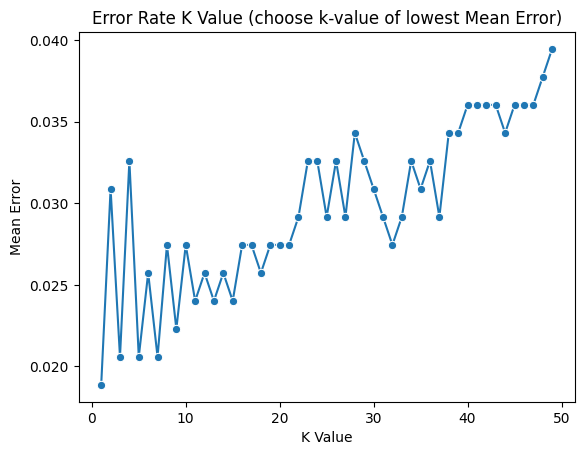

In [16]:

# Adjust this to 50 or even 150 if you have lots of data rows
max_iterations = 50

# List to save the error values in the loop
error = []

# The default metric in scikit-learn
metric_selection = "euclidean"

# Calculating error for K values between 1 and 40
for i in range(1, max_iterations):

     # Try with current k-value, train the model and make a test prediction
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=i, metric=metric_selection))
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)

    # Save the error value for this k-value
    error.append(np.mean(pred_i != y_test))
    
# Plot all the k-values and their error values
sns.lineplot(x=range(1, max_iterations), y=error, marker='o')
plt.title('Error Rate K Value (choose k-value of lowest Mean Error)')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

# Choose best k-value based on metrics
# we have to add +1 to k-value, since argmin() returns an index
# which starts from 0, but k-values start from 1
print("Based on iterations, best k-value is this:")
k_value = np.argmin(error) + 1
print(k_value)

In [17]:
# Pipeline
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=k_value, algorithm='brute')
)

# Metric grid (Didn't use minkowski, since it's a pain.)
param_grid = {
    'kneighborsclassifier__metric': [
        'euclidean',
        'manhattan',
        'chebyshev',
        'cosine',
        'hamming',
        'canberra',
        'braycurtis'
    ]
}

# Grid search
grid = GridSearchCV(
    model,
    param_grid,         
    cv=5,               # 5 folds here. train on 4, test on 1, then rotate.
    scoring='accuracy', # Accuracy is the % of correct predictions.
    n_jobs=-1,          # Uses all processors. No sense using only some of them.
)

grid.fit(X_train, y_train)

print("Best metric:", grid.best_params_)
print("Best score:", grid.best_score_)

Best metric: {'kneighborsclassifier__metric': 'chebyshev'}
Best score: 0.9985294117647058


#### Metrics

#### ROC AUC

In [19]:
# ROC AUC score
roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])

0.9952049611791025

#### Accuracy Score report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       447
           1       0.99      0.99      0.99       136

    accuracy                           1.00       583
   macro avg       1.00      1.00      1.00       583
weighted avg       1.00      1.00      1.00       583


Model overall accuracy: 99.66%


<Axes: >

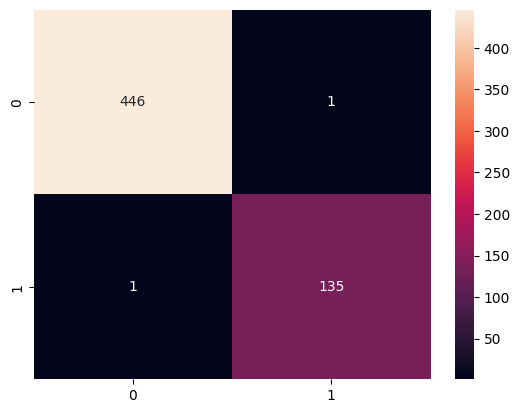

In [22]:
# Metrics
print(classification_report(y_test, predictions))
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

# Creating a confusion matrix.
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

#### Personal Analysis:

<strong style='color:red ; background-color:black;'> Very suspicious. </strong> Let's take a look and see if we leaked anything

In [25]:
list(X.columns)

['X_Minimum',
 'X_Maximum',
 'Y_Minimum',
 'Y_Maximum',
 'Pixels_Areas',
 'X_Perimeter',
 'Y_Perimeter',
 'Sum_of_Luminosity',
 'Minimum_of_Luminosity',
 'Maximum_of_Luminosity',
 'Length_of_Conveyer',
 'TypeOfSteel_A300',
 'TypeOfSteel_A400',
 'Steel_Plate_Thickness',
 'Edges_Index',
 'Empty_Index',
 'Square_Index',
 'Outside_X_Index',
 'Edges_X_Index',
 'Edges_Y_Index',
 'Outside_Global_Index',
 'LogOfAreas',
 'Log_X_Index',
 'Log_Y_Index',
 'Orientation_Index',
 'Luminosity_Index',
 'SigmoidOfAreas',
 'Pastry',
 'Z_Scratch',
 'K_Scatch',
 'Stains',
 'Dirtiness',
 'Other_Faults']

#### Suspiciously high results?

`Bumps`, the target variable is clearly gone. 

* VIF test verified there's no redundant connection between the target variable and any features...

* Correlations don't show any abnormally high corrs between target variable and the features...

* Maybe Tuomas can find something here? Not seeing a data leak. (It's way too high, SOMETHING happened)

* Why are there pastries in this slab of steel? :( SUSPICIOUS


---

#### Personal Analysis

The obvious, the metrics are suspiciously high. I'll continue to look into that and research the topic. Maybe I'll find something out before it gets graded. If not, DARN. Here are some other thoughts:

* We can see that the number of neighbors used here is quite low. I suspect that's because the number of rows were very small, (~1k rows)

* Gridsearch optimized accuracy report scores by 9%. That is enormous. 

* No RFE or PCA was used, and I feel that was a good call. 20-30 features is still managable!

* I'm using less comments and explaining stuff a little less now, since it can be overwhelming. Let's see if that helps with readability. (If I know only I am reading it, I'm gonna comment a lot though.)

#### Tester Row

<i>

<strong style='color:red ; background-color:black;'> 

#### Disclosure: 

I used AI to make this test row (I cannot be bothered to do this manually), ChatGPT v5.0.

#### Prompt:

 /paste X.columns/. 
 
 Make me a synthetic test row dictionary with some example outputs.
 
</strong>

In [ ]:
# I USED AI HERE, CHATGPT 5.0. 
# Creating a tester row to confirm the model works.
tester_row = {
    'X_Minimum': 10,
    'X_Maximum': 50,
    'Y_Minimum': 20,
    'Y_Maximum': 80,
    'Pixels_Areas': 1500,
    'X_Perimeter': 120,
    'Y_Perimeter': 200,
    'Sum_of_Luminosity': 5000,
    'Minimum_of_Luminosity': 50,
    'Maximum_of_Luminosity': 255,
    'Length_of_Conveyer': 1000,

    # One-hot encoded steel types (only one should be 1)
    'TypeOfSteel_A300': 1,
    'TypeOfSteel_A400': 0,

    'Steel_Plate_Thickness': 5.0,
    'Edges_Index': 0.5,
    'Empty_Index': 0.1,
    'Square_Index': 0.8,
    'Outside_X_Index': 0.2,
    'Edges_X_Index': 0.3,
    'Edges_Y_Index': 0.4,
    'Outside_Global_Index': 0.25,
    'LogOfAreas': 7.3,
    'Log_X_Index': 2.1,
    'Log_Y_Index': 2.5,
    'Orientation_Index': 0.6,
    'Luminosity_Index': 0.7,
    'SigmoidOfAreas': 0.9,

    # Target classes (set all to 0 if you're predicting them)
    'Pastry': 0,
    'Z_Scratch': 0,
    'K_Scatch': 0,
    'Stains': 0,
    'Dirtiness': 0,
    'Other_Faults': 0
}

tester_row = pd.DataFrame([tester_row])

result = grid.predict(tester_row)[0]

# This is my own code again.

# Translates the tester dict result to human language.
if result == 0:
    result = "No bumps!"
else:
    result = "Bumps."

# Print
print("Prediction:", result)

Prediction: No bumps!
